In [1]:
import torch
import os 
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt 
from torchvision import datasets , transforms
import random
import glob
from pathlib import Path
import numpy as np 
import seaborn as sns
from torch.utils.data import DataLoader
import torch.optim as optim 
from torchinfo import summary
from tqdm.auto import tqdm
from timeit import default_timer as timer

d:\Users\DEBJIT DAS\PetVision Classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

2.7.1+cu118
cuda


## Loading the Dataset

In [5]:
train_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set"
test_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set"
train_dir,test_dir


('D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\training_set\\training_set',
 'D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\test_set\\test_set')

## Understanding the Dataset

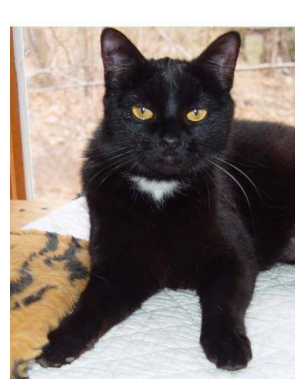

In [6]:
image = Image.open(r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\cats\cat.3626.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

Image path : D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\dogs\dog.2111.jpg
Image Class : dogs
Image Height : 374
Image Width : 500


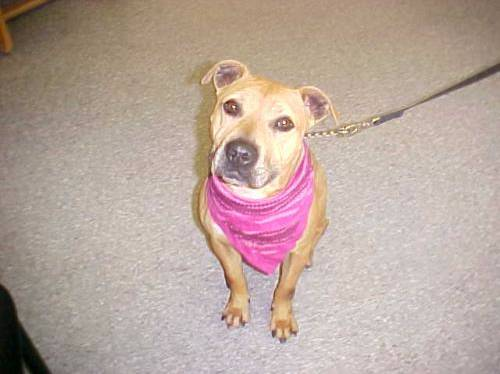

In [7]:
random.seed(42)
image_path_list = glob.glob(
    r'D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\*/*.jpg'
)
random_image_path = random.choice(image_path_list)
image_class = Path(random_image_path).parent.stem



img = Image.open(random_image_path)
print(f"Image path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Width : {img.width}")
img


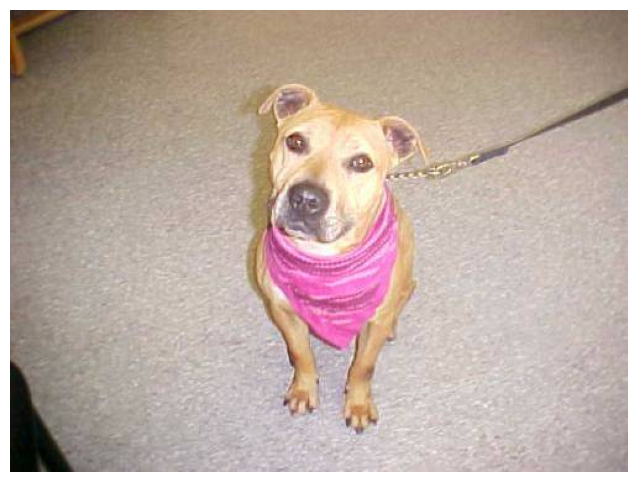

In [8]:
sns.set_theme()
image_to_array = np.array(img)
plt.figure(figsize=(8,6))
plt.imshow(image_to_array)
plt.axis(False)
plt.show()

## Transforming Data

In [9]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

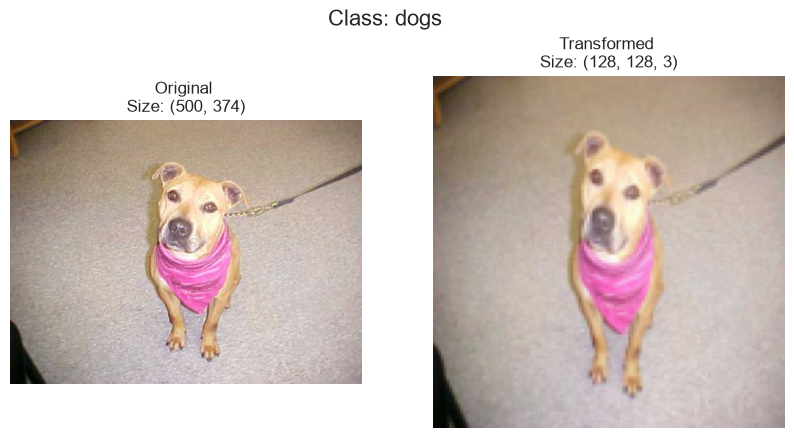

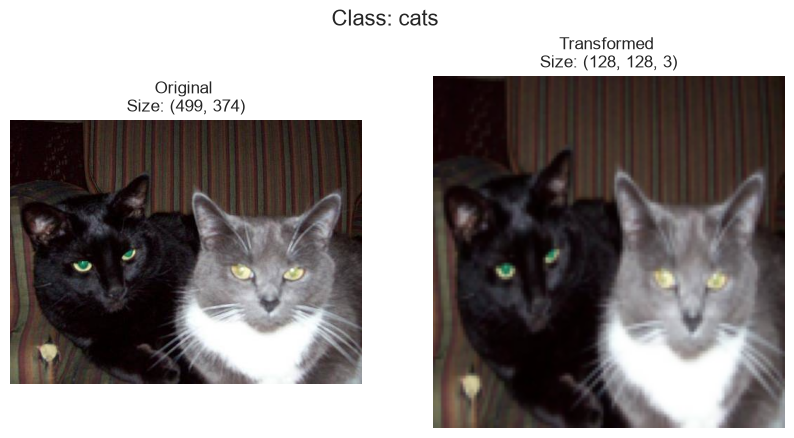

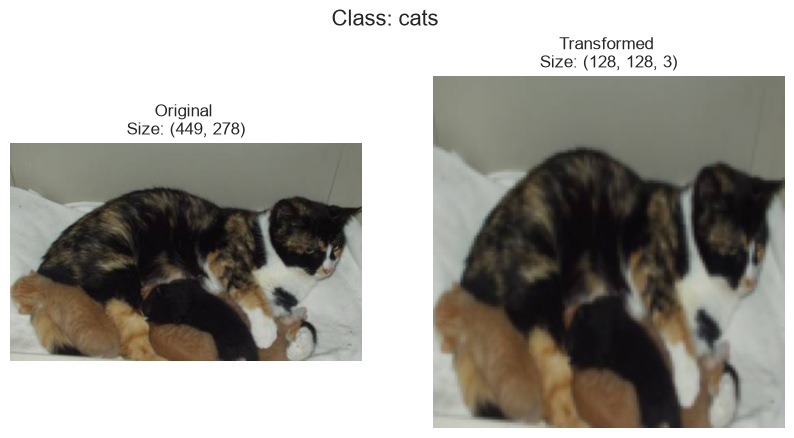

In [10]:

def transform_all_images(image_paths, transform, n=3,seed = 42):
    random.seed(seed)
    sampled_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    for img_path in sampled_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed = transform(f)  
            transformed = transformed.permute(1, 2, 0).numpy()  
            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed \nSize: {transformed.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            plt.show()

transform_all_images(image_path_list, transform=transform_images, n=3)

##  Loading Image Data

In [11]:
train_data = datasets.ImageFolder(root=train_dir, transform=transform_images,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_images)
print(f"Train Data {train_data}\n Test Data {test_data}")

Train Data Dataset ImageFolder
    Number of datapoints: 8005
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test Data Dataset ImageFolder
    Number of datapoints: 2021
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [12]:
print(f"Class name : {train_data.classes}")
print(f"Class name : {train_data.class_to_idx}")
print(f"The Lenght of Traning and Test Data Set  :",len(train_data),len(test_data))


Class name : ['cats', 'dogs']
Class name : {'cats': 0, 'dogs': 1}
The Lenght of Traning and Test Data Set  : 8005 2021


In [13]:
img, label = train_data[0]
print(f"Image Tensor: {img}")
print(f"Image Shape: {img.shape}")
print(f"Image DataType: {img.dtype}")
print(f"Image label: {label}")
print(f" Label datatype : {label}")

Image Tensor: tensor([[[0.7882, 0.7765, 0.6196,  ..., 0.1608, 0.1608, 0.1569],
         [0.7882, 0.7529, 0.6118,  ..., 0.1490, 0.1490, 0.1529],
         [0.7882, 0.7373, 0.6118,  ..., 0.1333, 0.1333, 0.1490],
         ...,
         [0.1725, 0.2627, 0.2392,  ..., 0.0784, 0.0784, 0.0863],
         [0.1725, 0.1804, 0.2196,  ..., 0.0863, 0.0902, 0.1098],
         [0.1765, 0.1804, 0.2431,  ..., 0.0863, 0.0902, 0.1176]],

        [[0.7725, 0.7686, 0.6235,  ..., 0.1725, 0.1765, 0.1765],
         [0.7686, 0.7373, 0.6118,  ..., 0.1608, 0.1647, 0.1725],
         [0.7608, 0.7137, 0.6039,  ..., 0.1451, 0.1490, 0.1686],
         ...,
         [0.1255, 0.2078, 0.1725,  ..., 0.0706, 0.0706, 0.0784],
         [0.1255, 0.1255, 0.1569,  ..., 0.0784, 0.0824, 0.1020],
         [0.1373, 0.1255, 0.1804,  ..., 0.0784, 0.0824, 0.1098]],

        [[0.6431, 0.6706, 0.5843,  ..., 0.1922, 0.1765, 0.1608],
         [0.6510, 0.6471, 0.5804,  ..., 0.1804, 0.1647, 0.1569],
         [0.6510, 0.6392, 0.5843,  ..., 0.16

In [14]:

num_of_workers = os.cpu_count()
train_loader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=num_of_workers)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False,num_workers=num_of_workers)
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x2e3bd82f390>,
 <torch.utils.data.dataloader.DataLoader at 0x2e3df81b490>)

In [15]:
img, label = next(iter(train_loader))
print(f"Image shape {img.shape}")
print(f"Label shape: {label}")

Image shape torch.Size([32, 3, 128, 128])
Label shape: tensor([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 0, 1])


## Model Building with Data Augmentation

In [16]:
image_height = 224
image_width = 224 
image_size = (image_height,image_width) 

train_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.TrivialAugmentWide(),
       transforms.ToTensor() 
    ]
)
test_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.ToTensor() 
    ]
)

In [17]:
train_data_augmentation = datasets.ImageFolder(train_dir,transform=train_augmentation)
test_data_augmentation = datasets.ImageFolder(test_dir,transform=test_augmentation)

In [18]:
torch.manual_seed(42)

In [19]:
train_augmented_loader = DataLoader(train_data_augmentation,batch_size=32,shuffle=True,num_workers=num_of_workers,pin_memory=True)
test_augmented_loader = DataLoader(test_data_augmentation,batch_size=32,shuffle=False,num_workers=num_of_workers,pin_memory=True)
train_augmented_loader,test_augmented_loader

(<torch.utils.data.dataloader.DataLoader at 0x2e3e7dfb890>,
 <torch.utils.data.dataloader.DataLoader at 0x2e3e7dfac50>)

In [3]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2)
        )

       
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_5 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 2)  
        )

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = self.conv_layer_5(x)

        x = self.classifier(x)

        return x


model = ImageClassifier().to(device)

In [21]:
summary(model,input_size= [1,3,image_height,image_width])

Layer (type:depth-idx)                   Output Shape              Param #
ImageClassifier                          [1, 2]                    --
├─Sequential: 1-1                        [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 32, 224, 224]         896
│    └─ReLU: 2-2                         [1, 32, 224, 224]         --
│    └─BatchNorm2d: 2-3                  [1, 32, 224, 224]         64
│    └─MaxPool2d: 2-4                    [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-5                       [1, 64, 112, 112]         18,496
│    └─ReLU: 2-6                         [1, 64, 112, 112]         --
│    └─BatchNorm2d: 2-7                  [1, 64, 112, 112]         128
│    └─MaxPool2d: 2-8                    [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 128, 28, 28]          --
│    └─Conv2d: 2-9                       [1, 128, 56, 56]          73,856
│    

 ## Train and Evaluate Model

In [22]:
def train_step(model,dataloader,loss_fn,optimizer):
    
    model.train()
    
    total_loss = 0
    total_image = 0
    total_correct = 0
    
    for images, labels in dataloader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        prediction = model(images)
        
        loss = loss_fn(prediction,labels)
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
        
        predicted_labels = prediction.argmax(dim = 1)
        
        total_correct += (predicted_labels == labels).sum().item()
        
        total_image += labels.size(0)
        
    avg_loss = total_loss/ len(dataloader)
    
    accuracy = total_correct/total_image
    
    return avg_loss, accuracy       

In [23]:
def test_step(model, dataloader, loss_fn):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_images = 0

    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images)

            loss = loss_fn(predictions, labels)

            total_loss += loss.item()

            predicted_labels = predictions.argmax(dim=1)

            total_correct += (predicted_labels == labels).sum().item()

            total_images += labels.size(0)

    average_loss = total_loss / len(dataloader)
    accuracy = total_correct / total_images

    return average_loss, accuracy

In [24]:
def train(model,train_loader,test_loader,loss_fn,optimizer,epochs):
    results = {
        "train_loss":[],
        "train_acc":[],
        "test_loss":[],
        "test_acc":[]
    }
    
    for epoch in tqdm(range(epochs)):
        train_loss ,train_acc = train_step(model,train_loader,loss_fn,optimizer)
        test_loss ,test_acc = test_step(model,test_loader,loss_fn)
        
        
        print(f"\n Epoch  {epoch + 1}/{epochs}")
        
        print(f"Train_loss: {train_loss:.4f} " )
        print(f"Train_acc: {train_acc:.4f} " )
        print(f"Test_loss: {test_loss:.4f}  " )
        print(f"Test_acc: {test_acc:.4f}  " )
        
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
    return results
    
        

In [25]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
num_epochs = 25 
learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(),lr=learning_rate )

In [ ]:
start_time = timer()

model_result = train(model=model,
                     train_loader=train_augmented_loader,
                     test_loader= test_augmented_loader,
                     optimizer= optimizer,
                     loss_fn=loss_fn,
                     epochs=num_epochs
                     )

end_time = timer()


print(f"\nTraining Time : {end_time-start_time:.2f} seconds")

  4%|▍         | 1/25 [02:26<58:27, 146.16s/it]


 Epoch  1/25
Train_loss: 2.1046 
Train_acc: 0.5906 
Test_loss: 2.4733  
Test_acc: 0.6299  


  8%|▊         | 2/25 [04:30<50:59, 133.04s/it]


 Epoch  2/25
Train_loss: 1.8527 
Train_acc: 0.6127 
Test_loss: 2.1919  
Test_acc: 0.6848  


 12%|█▏        | 3/25 [06:32<47:05, 128.41s/it]

...


 Epoch  23/25
Train_loss: 0.3542 
Train_acc: 0.8377 
Test_loss: 0.4882  
Test_acc: 0.8229  


 96%|█████████▌| 24/25 [1:01:40<02:37, 157.10s/it]


 Epoch  24/25
Train_loss: 0.3373 
Train_acc: 0.8435 
Test_loss: 0.3351  
Test_acc: 0.8535  


100%|██████████| 25/25 [1:09:56<00:00, 167.85s/it]


 Epoch  25/25
Train_loss: 0.3168 
Train_acc: 0.8567 
Test_loss: 0.3394  
Test_acc: 0.8629  

Training Time : 4196.33 seconds


In [ ]:
# os.makedirs("saved_models", exist_ok=True)


# torch.save(
#     model.state_dict(),
#     "saved_models/image_classifier.pth"
# )

# print(" Model saved successfully!")

 Model saved successfully!


Dog


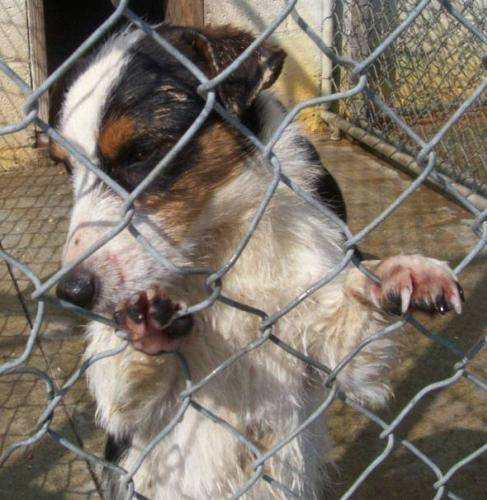

In [4]:

model = ImageClassifier().to(device) 
model.load_state_dict(torch.load("saved_models/image_classifier.pth", map_location=device))

model.eval()



transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


image = Image.open(r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\dogs\dog.885.jpg").convert("RGB") 


image = transform(image)


image = image.unsqueeze(0) 


image = image.to(device)


with torch.inference_mode():
    output = model(image)

prediction = output.argmax(dim=1).item()

if prediction == 0:
    print("Cat")
else:
    print("Dog")
    
img = Image.open(r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\dogs\dog.885.jpg")
img